# Rede neural para regressão

## Introdução

A rede neural para regressão basicamente é igual à da classificação, tendo como diferencial principal que o neurônio de saída não precisa de função de ativação, pois ele pode aceitar quaisquer valores resultante das soma dos neurônios anteriores pelos pesos.

### A função Loss

O loss também precisa mudar, aqui usamos o MSE (*mean squared error*), ou soma dos erros quadráticos.

O MSE é basicamente
$$
MSE = \sum{erros^2}
$$

No caso o gradiente é calculado como:
$$
gradiente = -\frac{2}{N} \sum{(erro \cdot x)}
$$

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

# Carregar dados para regressão
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Carregar no pandas
import pandas as pd
df = pd.DataFrame(X, columns=housing.feature_names)
df['target'] = y
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


target: valor em 100000 dólares

In [40]:
# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definir o modelo
model = keras.Sequential([
    keras.layers.Dense(30, activation='relu', input_shape=X_train_scaled.shape[1:]),
    keras.layers.Dense(10, activation='relu'),
    keras.layers.Dense(1) # Saída da regressão (não tem ativação)
])

# Compilar
model.compile(optimizer='adam', loss='mse') # Mean Squared Error for regression

# Treinar
history = model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)

# Avaliar
loss = model.evaluate(X_test_scaled, y_test)
print(f'Test Loss: {loss}')

# Fazer as predições
predictions = model.predict(X_test_scaled)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.2421 - val_loss: 0.6525
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6518 - val_loss: 0.4734
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4337 - val_loss: 0.4390
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4001 - val_loss: 0.4254
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3931 - val_loss: 0.4161
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3759 - val_loss: 0.4080
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3563 - val_loss: 0.4170
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3528 - val_loss: 0.3962
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3541 - val_loss: 0.3889
Epoch 10/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3488 - val_loss: 0.3814
Epoch 11/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3560 - val_loss: 0.3927
Epoch 12/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.

## Gráfico predito vs observado

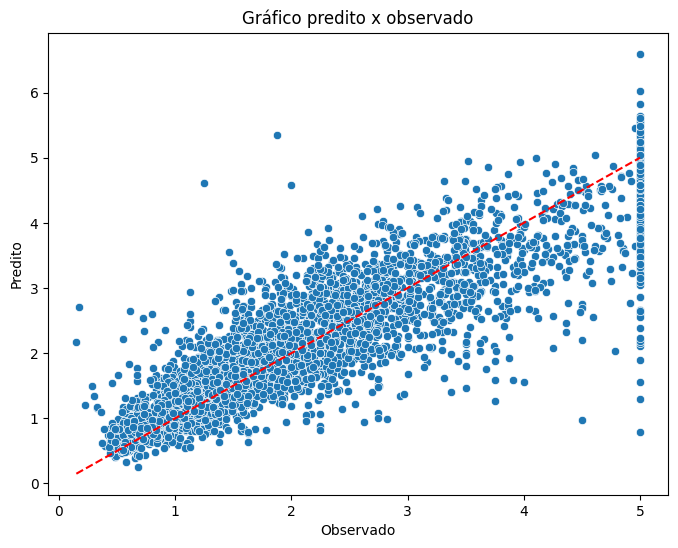

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=predictions.flatten())
plt.xlabel("Observado")
plt.ylabel("Predito")
plt.title("Gráfico predito x observado")

# Linha diagonal
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

plt.show()

### Todos os dados

In [ ]:
rmse = np.sqrt(((predictions - y_test) ** 2).mean())
rmse

np.float64(1.540307965873957)

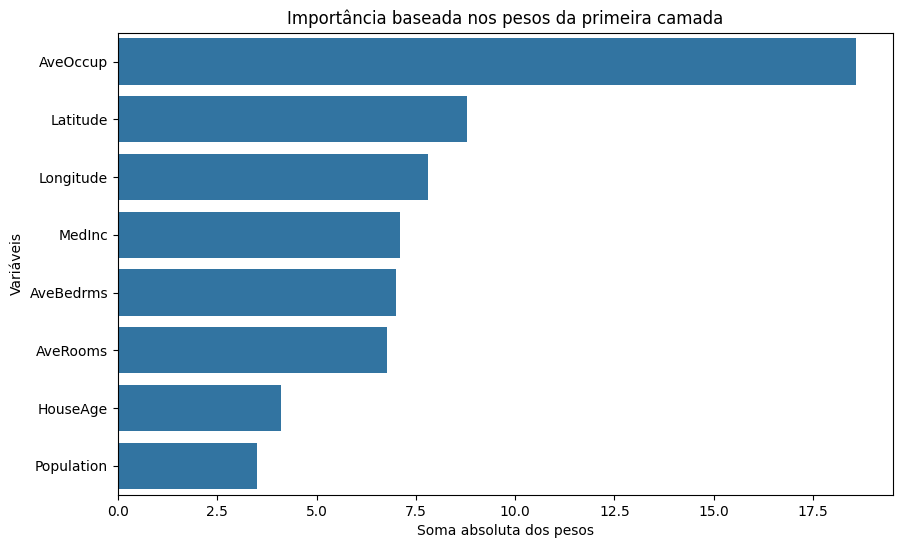

In [ ]:
# Importância baseada nos pesos das primeiras camadas
weights = model.layers[0].get_weights()[0]
feature_names = housing.feature_names

# Valor absoluto (sem sinal)
abs_weights = np.abs(weights)

# A importância = soma dos pesos
feature_importance = np.sum(abs_weights, axis=1)

# Transformar em pandas
feature_importance_series = pd.Series(feature_importance, index=feature_names)

# Ver a importância
sorted_feature_importance = feature_importance_series.sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_feature_importance.values, y=sorted_feature_importance.index)
plt.title("Importância baseada nos pesos da primeira camada")
plt.xlabel("Soma absoluta dos pesos")
plt.ylabel("Variáveis")
plt.show()